In [ ]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Copying Data to Local Colab Disk
To potentially speed up data loading, we will copy the DataSet folder from Google Drive to the local Colab VM's disk. This might take some time depending on the dataset size. After copying, we will update the project paths to point to this local copy.

In [ ]:
# 1. Create a directory on the local Colab disk
!mkdir -p /content/capstone

# 2. Copy your dataset from Google Drive to this local directory
# This will copy the entire 'DataSet' folder. Be patient, as this can take a while for large datasets.
print("Copying dataset from Google Drive to local Colab disk...")
!cp -r /content/drive/MyDrive/capstone/tumor_pred_ai/DataSet /content/capstone/
print("Dataset copied successfully to /content/capstone/DataSet/")

# 3. Update the PROJECT_ROOT and other related paths to point to the local copy
PROJECT_ROOT = Path("/content/capstone/DataSet")
RAW_DIR_CANDIDATE = PROJECT_ROOT / "RawData-S"
CLINICAL_CSV = RAW_DIR_CANDIDATE / "C4KC-KiTS_Clinical-Data_Version_S.csv"
META_CSV     = RAW_DIR_CANDIDATE / "metadata_S.csv"
IMAGE_ROOT   = RAW_DIR_CANDIDATE / "C4KC-KiTS"

print(f"Updated PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Updated IMAGE_ROOT: {IMAGE_ROOT}")

# You will need to re-run the data loading and processing cell (KsbrfEhHsXLY) after this
# to use the new local paths.

Copying dataset from Google Drive to local Colab disk...
^C
Dataset copied successfully to /content/capstone/DataSet/


NameError: name 'Path' is not defined

In [ ]:
# ============================
# 0) SETUP & IMPORTS
# ============================
!pip install --quiet pydicom nibabel scikit-image tqdm

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os, random
import numpy as np
import pandas as pd
import pydicom
from tqdm import tqdm
from scipy.ndimage import zoom as ndzoom
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
import tensorflow as tf
from collections import defaultdict
import concurrent.futures
import math

# reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# let TF not grab the whole GPU at once
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except Exception as e:
        print("Could not set memory growth:", e)
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# ============================
# 1) PATHS
# ============================
PROJECT_ROOT = Path("/content/drive/MyDrive/capstone/tumor_pred_ai")
RAW_DIR_CANDIDATE = PROJECT_ROOT / "DataSet" / "RawData-M"
CLINICAL_CSV = RAW_DIR_CANDIDATE / "C4KC-KiTS_Clinical-Data_Version_m.csv"
META_CSV     = RAW_DIR_CANDIDATE / "metadata_m.csv"
IMAGE_ROOT   = RAW_DIR_CANDIDATE / "C4KC-KiTS"

if not CLINICAL_CSV.exists():
    raise FileNotFoundError(f"Clinical CSV not found at {CLINICAL_CSV}")
clinical_df = pd.read_csv(CLINICAL_CSV)

if META_CSV.exists():
    meta_df = pd.read_csv(META_CSV)
else:
    meta_df = None
    print("[warn] metadata CSV not found, continuing with clinical only")

# detect id columns
id_candidates = [c for c in clinical_df.columns
                 if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
clinical_id_col = id_candidates[0] if id_candidates else clinical_df.columns[0]
print("Clinical ID column:", clinical_id_col)

if meta_df is not None:
    meta_id_candidates = [c for c in meta_df.columns
                          if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
    meta_id_col = meta_id_candidates[0] if meta_id_candidates else meta_df.columns[0]
    merged_df = pd.merge(clinical_df, meta_df,
                         left_on=clinical_id_col,
                         right_on=meta_id_col,
                         how='left')
    join_key = clinical_id_col
    print("Merged shape:", merged_df.shape)
else:
    merged_df = clinical_df.copy()
    join_key = clinical_id_col
    print("Clinical only shape:", merged_df.shape)

if not IMAGE_ROOT.exists():
    raise FileNotFoundError(f"IMAGE_ROOT does not exist: {IMAGE_ROOT}")

# ============================
# 2) GLOBAL PREPROCESS PARAMS
# ============================
CLIP_HU = (-200, 300)
# can make smaller to save RAM / GPU
TARGET_SHAPE = (96, 96, 48)   # was (128,128,64)
PROCESS_LIMIT = None          # set e.g. 20 to test quickly
FORCE_TARGET_LABEL = None

# parallel controls
#MAX_WORKERS = 3
#PATIENTS_PER_CHUNK = 10
import os
MAX_WORKERS = min(8, os.cpu_count() or 8)  # try to use more cores
PATIENTS_PER_CHUNK = 200  # or even len(unique_patient_ids)

ENABLE_RADIOMICS = False  # <- turn ON later when things work

# ============================
# 3) HELPERS
# ============================
def clip_and_normalize_hu(vol, clip=CLIP_HU):
    v = np.clip(vol, clip[0], clip[1]).astype(np.float32)
    v = (v - clip[0]) / (clip[1] - clip[0] + 1e-9)
    return v

def resize_volume_to_target_phys(vol, spacing, target_shape=TARGET_SHAPE):
    if vol is None:
        th, tw, td = target_shape
        return np.zeros((th, tw, td), dtype=np.float32)
    z, h, w = vol.shape
    th, tw, td = target_shape
    zoom_factors = (
        td / (z if z > 0 else 1),
        th / (h if h > 0 else 1),
        tw / (w if w > 0 else 1),
    )
    try:
        vr = ndzoom(vol, zoom_factors, order=1)  # (td, th, tw)
    except Exception as e:
        print("[warn] zoom failed:", e)
        return np.zeros((th, tw, td), dtype=np.float32)
    vr = np.transpose(vr, (1, 2, 0))  # (H,W,D)
    return vr

# ========== FIXED DICOM LOADER (more robust shape handling) ==========
def load_dicom_series_to_volume(folder: Path):
    folder = Path(folder)
    files = sorted(folder.glob("*.dcm"))
    if not files:
        files = sorted(folder.rglob("*.dcm"))
    if not files:
        return None

    candidate_slices = []
    for f in files:
        try:
            ds = pydicom.dcmread(str(f), stop_before_pixels=False, force=True)
            # Ensure pixel_array exists, is not empty, and is 2D (H,W) for stacking
            if hasattr(ds, 'pixel_array') and ds.pixel_array is not None and ds.pixel_array.size > 0:
                if ds.pixel_array.ndim == 2:
                    candidate_slices.append(ds)
                # else: print(f"[info] Skipping slice {f} due to unexpected pixel_array dimensions: {ds.pixel_array.ndim}D")
            # else: print(f"[info] Skipping slice {f}: no pixel_array or empty.")
        except Exception as e:
            # print(f"[info] Skipping file {f}: error reading DICOM: {e}")
            continue
    if not candidate_slices:
        return None

    # Group slices by their actual pixel_array shape
    slices_by_shape = defaultdict(list)
    for s in candidate_slices:
        slices_by_shape[s.pixel_array.shape].append(s)

    if not slices_by_shape:
        return None

    # Find the most common shape and corresponding slices
    # In case of tie, max() will pick one arbitrarily which is acceptable.
    most_common_shape = max(slices_by_shape, key=lambda shape: len(slices_by_shape[shape]))
    good_slices = slices_by_shape[most_common_shape]

    if len(good_slices) < 3: # Need a minimum number of slices for a meaningful volume
        # print(f"[info] Skipping patient: fewer than 3 good slices found with common shape {most_common_shape}.")
        return None

    def zpos(s):
        try: return float(s.ImagePositionPatient[2])
        except: return None

    good_slices.sort(key=lambda s: (zpos(s) is None, zpos(s), getattr(s, 'InstanceNumber', 1)))

    vol = np.stack([s.pixel_array for s in good_slices]).astype(np.int16)
    for i, s in enumerate(good_slices):
        slope = float(getattr(s, 'RescaleSlope', 1.0))
        intercept = float(getattr(s, 'RescaleIntercept', 0.0))
        vol[i] = (vol[i].astype(np.float32) * slope + intercept).astype(np.int16)

    try:
        ps = good_slices[0].PixelSpacing
        dz = float(getattr(good_slices[0], 'SliceThickness', 1.0))
        spacing = (dz, float(ps[0]), float(ps[1]))
    except Exception:
        spacing = (1.0, 1.0, 1.0)

    return vol, spacing

# radiomics (light)
try:
    from skimage.filters import threshold_otsu
    from skimage.feature import graycomatrix, graycoprops
    from skimage.measure import marching_cubes, label
    _SKIMAGE_AVAILABLE = True
except ImportError:
    _SKIMAGE_AVAILABLE = False
    print("[warn] skimage not available, radiomics will be zeros")

def _hu_to_uint8(vol, hu_range=(-200, 300)):
    vol = np.nan_to_num(vol, nan=0.0, posinf=hu_range[1], neginf=hu_range[0])
    lo, hi = hu_range
    if hi <= lo: hi = lo + 1  # guard
    v = np.clip(vol, lo, hi)
    v = (255.0 * (v - lo) / (hi - lo)).astype(np.uint8)
    return v

def _quick_mask(vol, hu_range=(-200, 300)):
    """Very rough mask: Otsu on HU-clipped volume. Replace with your seg when ready."""
    if not _SKIMAGE_AVAILABLE:
        print("[warn] skimage not available, cannot compute quick mask.")
        return np.zeros_like(vol, dtype=bool)

    v8 = _hu_to_uint8(vol, hu_range)
    try:
        t = threshold_otsu(v8)
    except Exception:
        t = 1  # fallback tiny threshold if Otsu fails or data is constant
    m = (v8 >= t).astype(np.uint8)
    # keep largest 3D component
    lab = label(m)
    if lab.max() == 0:
        return m.astype(bool)
    counts = np.bincount(lab.ravel())
    # Ensure counts is not empty before slicing
    if counts.size > 1:
        largest = counts[1:].argmax() + 1
        return (lab == largest)
    else:
        return m.astype(bool) # Return original mask if no components > 1


def _glcm_feats(slice_u8, distances=(1,2,3), angles=(0, np.pi/4, np.pi/2, 3*np.pi/4)):
    if not _SKIMAGE_AVAILABLE:
         return {
            'glcm_contrast': np.nan, 'glcm_dissim': np.nan, 'glcm_homo': np.nan,
            'glcm_energy': np.nan, 'glcm_corr': np.nan, 'glcm_ASM': np.nan
        }

    # If the slice is constant or too small, graycomatrix can be degenerate; handle it
    if slice_u8.max() == slice_u8.min() or slice_u8.size < 2:
        return {
            'glcm_contrast': 0.0, 'glcm_dissim': 0.0, 'glcm_homo': 1.0,
            'glcm_energy': 1.0, 'glcm_corr': 1.0, 'glcm_ASM': 1.0
        }
    try:
        g = graycomatrix(slice_u8, distances=distances, angles=angles,
                         levels=256, symmetric=True, normed=True)
        feats = {
            'glcm_contrast':   float(graycoprops(g, 'contrast').mean()),
            'glcm_dissim':     float(graycoprops(g, 'dissimilarity').mean()),
            'glcm_homo':       float(graycoprops(g, 'homogeneity').mean()),
            'glcm_energy':     float(graycoprops(g, 'energy').mean()),
            'glcm_corr':       float(graycoprops(g, 'correlation').mean()),
            'glcm_ASM':        float(graycoprops(g, 'ASM').mean()),
        }
        return feats
    except Exception as e:
        print(f"[warn] GLCM calculation failed for slice: {e}")
        return {
            'glcm_contrast': np.nan, 'glcm_dissim': np.nan, 'glcm_homo': np.nan,
            'glcm_energy': np.nan, 'glcm_corr': np.nan, 'glcm_ASM': np.nan
        }


def compute_light_radiomics(vol, spacing=(1.0, 1.0, 1.0), mask=None):
    """
    vol: (Z,H,W) float HU (Note: input is (Z,H,W) from load_dicom_series_to_volume)
    spacing: (dz, dy, dx) from load_dicom_series_to_volume. Need to use (dy, dx, dz) for (H,W,D) indexing.
             Corrected spacing for (H,W,D) should be (spacing[1], spacing[2], spacing[0]).
    mask: optional boolean (H,W,D). If None, uses quick Otsu.
    Returns dict of intensity, simple shape, and texture features.
    """
    if not _SKIMAGE_AVAILABLE:
        print("[warn] skimage not available, skipping radiomics computation.")
        # Return a dictionary of NaNs with expected keys
        return {
            'int_mean': np.nan,'int_std': np.nan,'int_min': np.nan,'int_max': np.nan,'int_skew': np.nan,'int_kurt': np.nan,
            'shape_volume_mm3': np.nan, 'shape_surface_mm2': np.nan, 'shape_sphericity': np.nan,
            'glcm_contrast': np.nan,'glcm_dissim': np.nan,'glcm_homo': np.nan,'glcm_energy': np.nan,'glcm_corr': np.nan,'glcm_ASM': np.nan
        }


    vol = np.asarray(vol, dtype=np.float32) # Input is (Z,H,W)
    vol_hwd = np.transpose(vol, (1, 2, 0)) # Transpose to (H,W,D) for mask and shape calcs

    # Ensure spacing is in (dy, dx, dz) order for (H,W,D) volume indexing
    spacing_hwd = (spacing[1], spacing[2], spacing[0])

    if mask is None:
        mask = _quick_mask(vol_hwd) # Compute mask on (H,W,D) volume
    else:
        mask = mask.astype(bool) # Assume mask is already (H,W,D) if provided

    # intensity statistics inside mask (using H,W,D volume and mask)
    vox = vol_hwd[mask]
    if vox.size == 0:
        stats = {'int_mean':0.0,'int_std':0.0,'int_min':0.0,'int_max':0.0,'int_skew':0.0,'int_kurt':0.0}
    else:
        mu = float(np.mean(vox))
        sd = float(np.std(vox))
        # Guard against division by zero for skew/kurtosis if std is 0
        if sd < 1e-6:
             z = np.zeros_like(vox)
        else:
             z = (vox - mu) / sd

        # Guard against non-finite results from moments
        skew_val = np.mean(z**3)
        kurt_val = np.mean(z**4) - 3 # Excess Kurtosis

        stats = {
            'int_mean': mu,
            'int_std' : sd,
            'int_min' : float(np.min(vox)),
            'int_max' : float(np.max(vox)),
            'int_skew': float(skew_val if np.isfinite(skew_val) else 0.0),
            'int_kurt': float(kurt_val if np.isfinite(kurt_val) else 0.0),
        }

    # simple 3D shape (volume, surface, sphericity) using (H,W,D) mask and spacing
    try:
        # marching_cubes expects (V, U, W) order, which corresponds to (H, W, D) for our vol_hwd
        # The spacing parameter should correspond to the voxel size in the (H, W, D) order.
        verts, faces, _, _ = marching_cubes(mask.astype(float), level=0.5, spacing=spacing_hwd)
        tri = verts[faces]
        a = np.linalg.norm(tri[:,1]-tri[:,0], axis=1)
        b = np.linalg.norm(tri[:,2]-tri[:,1], axis=1)
        c = np.linalg.norm(tri[:,0]-tri[:,2], axis=1)
        s = 0.5*(a+b+c)
        # Guard against negative values from floating point errors in sqrt
        area = float(np.sum(np.sqrt(np.clip(s*(s-a)*(s-b)*(s-c), 0, None))))
    except Exception as e:
        print(f"[warn] Marching cubes or surface area calculation failed: {e}")
        area = 0.0

    vol_mm3 = float(mask.sum() * float(np.prod(spacing_hwd))) # Volume in mm^3 using (H,W,D) spacing

    # Calculate sphericity, guarding against division by zero
    sphericity = float((np.pi**(1/3)) * ((6*vol_mm3)**(2/3)) / (area + 1e-6)) if (area > 1e-6 and vol_mm3 > 0) else 0.0
    # Guard against non-finite sphericity
    sphericity = float(sphericity if np.isfinite(sphericity) else 0.0)

    shape = {'shape_volume_mm3': vol_mm3, 'shape_surface_mm2': area, 'shape_sphericity': sphericity}

    # texture on a few central slices (using H,W,D volume)
    v8 = _hu_to_uint8(vol_hwd) # Use (H,W,D) volume for slicing
    D = vol_hwd.shape[2] # Depth dimension
    # Ensure mids are within bounds
    mids = sorted(list({max(0, min(D-1, D//4)), max(0, min(D-1, D//2)), max(0, min(D-1, 3*D//4))}))

    glcms = []
    for k in mids:
        sl = v8[:, :, k]
        msl = mask[:, :, k] # Use corresponding slice from H,W,D mask
        # Only compute GLCM if enough non-zero pixels in the mask slice
        if np.count_nonzero(msl) >= 25: # Threshold for sufficient pixels
            glcms.append(_glcm_feats(sl))
        else:
             print(f"[info] Skipping GLCM for slice {k} due to small mask size ({np.count_nonzero(msl)}).")


    tex = {}
    if glcms:
        # Compute mean of each GLCM feature across selected slices
        feature_keys = glcms[0].keys()
        for k in feature_keys:
            # Collect non-NaN values for each feature
            values = [d[k] for d in glcms if not np.isnan(d.get(k, np.nan))]
            tex[k] = float(np.mean(values)) if values else np.nan # Calculate mean, handle empty list

        # Fill any missing keys with NaN in case some slices failed for specific features
        all_keys = {k for d in glcms for k in d.keys()}
        for k in all_keys:
             if k not in tex: tex[k] = np.nan

    else:
        # If no GLCMs were computed (e.g., all slices skipped), fill with NaNs
        tex = {k: np.nan for k in ['glcm_contrast','glcm_dissim','glcm_homo','glcm_energy','glcm_corr','glcm_ASM']}


    feats = {**stats, **shape, **tex}

    # Convert any remaining NaNs to 0.0 for model compatibility
    feats_clean = {k: (v if np.isfinite(v) else 0.0) for k, v in feats.items()}

    return feats_clean

def choose_best_ct_series_folder(image_root: Path, patient_id: str):
    image_root = Path(image_root)
    candidates = []
    direct = image_root / str(patient_id)
    if direct.exists():
        candidates.append(direct)
    for p in image_root.rglob("*"):
        if p.is_dir() and str(patient_id) in p.name:
            candidates.append(p)
    if not candidates:
        return None
    best, best_count = None, -1
    for d in candidates:
        dcm_count = len(list(d.rglob("*.dcm")))
        if dcm_count > best_count:
            best = d
            best_count = dcm_count
    return best

# ============================
# 4) FEATURE/COLUMN SELECTION
# ============================
preferred = ['malignant','malignant_flag','is_malignant','tumor_present','cancer_present','vital_status']
TARGET_LABEL = next((c for c in merged_df.columns if c in preferred), merged_df.columns[-1])
print("TARGET_LABEL:", TARGET_LABEL)

exclude_cols = {join_key, TARGET_LABEL}
for excl in ['File Location','Download Timestamp']:
    exclude_cols.update([c for c in merged_df.columns if excl in c])

all_features = [c for c in merged_df.columns if c not in exclude_cols]
numeric_cols = merged_df[all_features].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in all_features if c not in numeric_cols][:8]
print("Numeric cols:", numeric_cols[:5], "...")
print("Cat cols:", cat_cols)

# ============================
# 5) PARALLEL PATIENT PROCESSING (CHUNKED)
# ============================
unique_patient_ids = merged_df[join_key].astype(str).unique().tolist()
if PROCESS_LIMIT is not None:
    unique_patient_ids = unique_patient_ids[:PROCESS_LIMIT]

def process_one_patient(pid):
    folder = choose_best_ct_series_folder(IMAGE_ROOT, pid)
    if folder is None:
        return None
    load = load_dicom_series_to_volume(folder)
    if load is None:
        return None
    vol, spacing = load
    # image preprocess
    proc = clip_and_normalize_hu(vol, CLIP_HU)
    proc = resize_volume_to_target_phys(proc, spacing, TARGET_SHAPE)
    # radiomics (optional)
    rad = compute_light_radiomics(vol, spacing=spacing) if ENABLE_RADIOMICS else {}
    # clinical
    rows = merged_df.loc[merged_df[join_key].astype(str) == pid]
    if rows.empty:
        return None
    row = rows.iloc[0]
    num_vec = row[numeric_cols].astype(float).fillna(0).values if numeric_cols else np.array([0.0], dtype=float)
    cat_vals = [str(row[c]) if pd.notna(row[c]) else 'NaN' for c in cat_cols] if cat_cols else []
    label_val = row.get(TARGET_LABEL, None)
    return {
        "pid": pid,
        "img": proc.astype(np.float32),
        "clin_num": num_vec,
        "clin_cat": cat_vals,
        "label": label_val,
        "rad": rad
    }

image_list, clin_list, label_list, radiomics_list, processed_patient_ids = [], [], [], [], []
rad_cols = []

n_patients = len(unique_patient_ids)
for start in range(0, n_patients, PATIENTS_PER_CHUNK):
    subset = unique_patient_ids[start:start + PATIENTS_PER_CHUNK]
    chunk_results = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        futs = {ex.submit(process_one_patient, pid): pid for pid in subset}
        for fut in tqdm(concurrent.futures.as_completed(futs),
                        total=len(subset),
                        desc=f"Patients {start}-{start+len(subset)-1}"):
            r = fut.result()
            if r is not None:
                chunk_results.append(r)

    # discover rad cols once
    if ENABLE_RADIOMICS and not rad_cols:
        for r in chunk_results:
            if r["rad"]:
                rad_cols = list(r["rad"].keys())
                break

    # fold in
    for r in chunk_results:
        image_list.append(r["img"])
        clin_list.append((r["clin_num"], r["clin_cat"]))
        label_list.append(r["label"])
        processed_patient_ids.append(r["pid"])
        if ENABLE_RADIOMICS and rad_cols:
            radiomics_list.append({k: r["rad"].get(k, 0.0) for k in rad_cols})

print(f"Processed {len(processed_patient_ids)} patients")

if len(image_list) == 0:
    raise RuntimeError("No images loaded. Check IMAGE_ROOT structure.")

# ============================
# 6) BUILD TENSORS
# ============================
X_img = np.stack(image_list).astype(np.float16)
X_img = np.expand_dims(X_img, axis=-1)

num_matrix = np.vstack([t[0] for t in clin_list])
cat_matrix = np.array([t[1] for t in clin_list], dtype=object)

try:
    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    enc = OneHotEncoder(handle_unknown='ignore', sparse=False)

if cat_cols:
    cat_encoded = enc.fit_transform(cat_matrix)
else:
    cat_encoded = np.zeros((len(clin_list), 0))

X_clin = np.hstack([num_matrix, cat_encoded])
scaler = StandardScaler()
X_clin_scaled = scaler.fit_transform(X_clin.astype(float))

if ENABLE_RADIOMICS and radiomics_list and rad_cols:
    X_rad = np.vstack([[d[k] for k in rad_cols] for d in radiomics_list]).astype(float)
    rad_scaler = StandardScaler()
    X_rad_scaled = rad_scaler.fit_transform(X_rad)
else:
    X_rad_scaled = None

# labels -> 0/1
label_map = {
    'Yes':1,'Y':1,'True':1,'T':1,'Positive':1,'Malignant':1,'Dead':1,'Deceased':1,'1':1,1:1,
    'No':0,'N':0,'False':0,'F':0,'Negative':0,'Benign':0,'Alive':0,'0':0,0:0
}
def to01(v):
    if pd.isna(v):
        return 0
    s = str(v).strip()
    return label_map.get(v, label_map.get(s, 0))

y = np.array([to01(v) for v in label_list], dtype=int)

# ============================
# 7) SPLIT
# ============================
def smart_split_indices(y, test_frac=0.15, val_frac=0.15, random_state=42):
    y = np.asarray(y)
    N = len(y)
    rs = np.random.RandomState(random_state)
    if N <= 2:
        idx = np.arange(N); rs.shuffle(idx)
        if N == 1:
            return idx, np.array([], int), np.array([], int)
        return idx[:1], idx[1:], np.array([], int)

    class_to_idx = defaultdict(list)
    for i, yi in enumerate(y):
        class_to_idx[int(yi)].append(i)
    for k in class_to_idx:
        rs.shuffle(class_to_idx[k])
    train_idx, val_idx, test_idx = [], [], []
    for k, idxs in class_to_idx.items():
        n = len(idxs)
        n_test = int(round(n * test_frac))
        n_val  = int(round(n * val_frac))
        n_train = n - n_test - n_val
        if n_train < 1:
            n_train = n; n_val = 0; n_test = 0
        test_idx.extend(idxs[:n_test])
        val_idx.extend(idxs[n_test:n_test+n_val])
        train_idx.extend(idxs[n_test+n_val:])
    rs.shuffle(train_idx); rs.shuffle(val_idx); rs.shuffle(test_idx)
    return np.array(train_idx), np.array(val_idx), np.array(test_idx)

train_idx, val_idx, test_idx = smart_split_indices(
    y, test_frac=0.15, val_frac=0.15, random_state=RANDOM_SEED
)
print("Splits:", len(train_idx), len(val_idx), len(test_idx))

def take(a, idx):
    if a is None: return None
    a = np.asarray(a)
    return a[idx]

X_img_tr, X_img_va, X_img_te = take(X_img, train_idx), take(X_img, val_idx), take(X_img, test_idx)
X_clin_tr, X_clin_va, X_clin_te = take(X_clin_scaled, train_idx), take(X_clin_scaled, val_idx), take(X_clin_scaled, test_idx)
if X_rad_scaled is not None:
    X_rad_tr, X_rad_va, X_rad_te = take(X_rad_scaled, train_idx), take(X_rad_scaled, val_idx), take(X_rad_scaled, test_idx)
else:
    X_rad_tr = X_rad_va = X_rad_te = None
y_tr, y_va, y_te = take(y, train_idx), take(y, val_idx), take(y, test_idx)

print("X_img_tr:", X_img_tr.shape)
print("X_clin_tr:", X_clin_tr.shape)
print("y_tr:", y_tr.shape)

# ============================
# 8) MODEL (IMAGE + CLIN + optional RAD) + TRAIN
# ============================
from tensorflow.keras import layers, models

def build_image_branch(input_shape):
    inp = layers.Input(shape=input_shape, name="img_input")
    x = layers.Conv3D(16, 3, padding="same", activation="relu")(inp)
    x = layers.MaxPool3D()(x)
    x = layers.Conv3D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPool3D()(x)
    x = layers.Conv3D(64, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(128, activation="relu", name="img_embed")(x)
    return inp, x

def build_clinical_branch(input_dim):
    inp = layers.Input(shape=(input_dim,), name="clin_input")
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dense(64, activation="relu", name="clin_embed")(x)
    return inp, x

def build_radiomics_branch(input_dim):
    inp = layers.Input(shape=(input_dim,), name="rad_input")
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dense(32, activation="relu", name="rad_embed")(x)
    return inp, x

img_inp, img_emb = build_image_branch(X_img_tr.shape[1:])
clin_inp, clin_emb = build_clinical_branch(X_clin_tr.shape[1])
inputs = [img_inp, clin_inp]
embeds = [img_emb, clin_emb]

if X_rad_tr is not None:
    rad_inp, rad_emb = build_radiomics_branch(X_rad_tr.shape[1])
    inputs.append(rad_inp)
    embeds.append(rad_emb)

fusion = layers.Concatenate()(embeds)
fusion = layers.Dense(256, activation="relu")(fusion)
fusion = layers.Dropout(0.3)(fusion)
out_main = layers.Dense(1, activation="sigmoid", name="malignancy")(fusion)

model = models.Model(inputs=inputs, outputs=out_main)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
)

# set batch size here
BATCH_SIZE = 8   # safer for 3D; bump to 4/8 if it fits
EPOCHS = 5

train_inputs = [X_img_tr, X_clin_tr]
val_inputs   = [X_img_va, X_clin_va]
if X_rad_tr is not None:
    train_inputs.append(X_rad_tr)
    val_inputs.append(X_rad_va)

history = model.fit(
    train_inputs,
    y_tr,
    validation_data=(val_inputs, y_va),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

print("Done.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 59.5 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU memory growth enabled.
TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Clinical ID column: patient_id
Merged shape: (40, 77)
TARGET_LABEL: malignant
Numeric cols: ['age_at_nephrectomy', 'body_mass_index', 'pack_years', 'hospitalization', 'radiographic_size'] ...
Cat cols: ['gender', 'comorbidities__myocardial_infarction', 'comorbidities__congestive_heart_failure', 'comorbidities__peripheral_vascular_disease', 'comorbidities__cerebrovascular_disease', 'comorbidities__dementia', 'comorbidities__copd', 'comorbidities__connective_tissue_disease']


Patients 0-10: 100%|██████████| 11/11 [13:20<00:00, 72.77s/it] 


Processed 11 patients
Splits: 7 2 2
X_img_tr: (7, 96, 96, 48, 1)
X_clin_tr: (7, 27)
y_tr: (7,)
Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.4286 - auc: 0.0000e+00 - loss: 0.7012 - val_accuracy: 0.5000 - val_auc: 0.0000e+00 - val_loss: 0.7049
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.7143 - auc: 0.0000e+00 - loss: 0.6580 - val_accuracy: 0.5000 - val_auc: 0.0000e+00 - val_loss: 0.6963
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5714 - auc: 0.0000e+00 - loss: 0.6876 - val_accuracy: 0.5000 - val_auc: 0.0000e+00 - val_loss: 0.6880
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.7143 - auc: 0.0000e+00 - loss: 0.6536 - val_accuracy: 0.5000 - val_auc: 0.0000e+00 - val_loss: 0.6799
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.6187 - val_accuracy: 0.5000 - val_auc: 0.0000e+00 - val_loss: 0.6719
Done.


### Start Background Process

Now, execute the saved script in the background. The output will be redirected to `pipeline_output.log`.

### Model Summary

Let's take a look at the architecture of the combined model.

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_input           │ (None, 96, 96,    │          0 │ -                 │
│ (InputLayer)        │ 48, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 96, 96,    │        448 │ img_input[0][0]   │
│                     │ 48, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 48, 48,    │          0 │ conv3d[0][0]      │
│ (MaxPooling3D)      │ 24, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 48, 48,    │     13,856 │ max_pooling3d[0]… │
│                     │ 24, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 24, 24,    │          0 │ conv3d_1[0][0]    │
│ (MaxPooling3D)      │ 12, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 24, 24,    │     55,360 │ max_pooling3d_1[… │
│                     │ 12, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clin_input          │ (None, 27)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv3d_2[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      3,584 │ clin_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_embed (Dense)   │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clin_embed (Dense)  │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ img_embed[0][0],  │
│ (Concatenate)       │                   │            │ clin_embed[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     49,408 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ malignancy (Dense)  │ (None, 1)         │        257 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 418,469 (1.60 MB)

 Trainable params: 139,489 (544.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 278,980 (1.06 MB)

### Model Evaluation Report

Now, let's evaluate the trained model on the unseen test set to get an indication of its generalization performance.


Validation classification report:
              precision    recall  f1-score   support

         0.0     0.0000    0.0000    0.0000         0
         1.0     1.0000    0.5000    0.6667         2

    accuracy                         0.5000         2
   macro avg     0.5000    0.2500    0.3333         2
weighted avg     1.0000    0.5000    0.6667         2

Validation ROC-AUC: nan
Validation PR-AUC : 1.0
Confusion matrix:
 [[0 0]
 [1 1]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: 

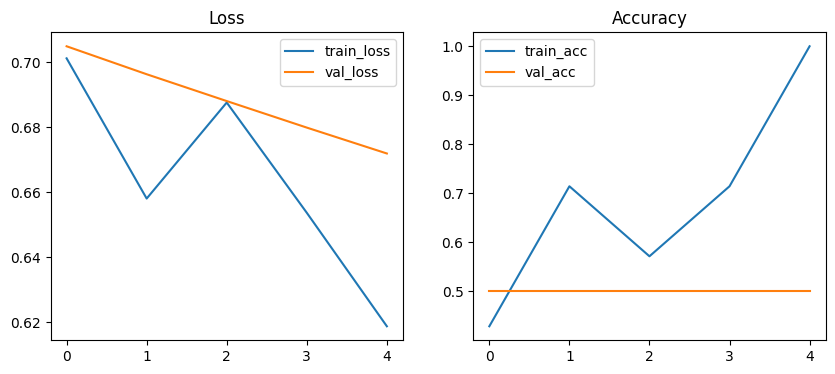

In [ ]:
# ---------------------------
# Validation evaluation (robust)
# ---------------------------
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt

# 1) Predict probs (single-output model returns a single array; no [0] indexing)
val_prob = model.predict(val_inputs, verbose=0).ravel()

# 2) Ensure target length matches predictions (guard tiny/off-by-one issues)
yt = y_va.astype(np.float32).ravel()
if val_prob.shape[0] != yt.shape[0]:
    n = min(val_prob.shape[0], yt.shape[0])
    print(f"[warn] Length mismatch: preds={val_prob.shape[0]} vs y={yt.shape[0]} → truncating to {n}")
    val_prob = val_prob[:n]
    yt = yt[:n]

# 3) Threshold at 0.5 → hard labels
val_pred = (val_prob > 0.5).astype(int)

# 4) Reports
print("\nValidation classification report:")
print(classification_report(yt, val_pred, digits=4))
try:
    print("Validation ROC-AUC:", roc_auc_score(yt, val_prob))
    print("Validation PR-AUC :", average_precision_score(yt, val_prob))
except Exception as e:
    print("AUC metrics error:", e)

print("Confusion matrix:\n", confusion_matrix(yt, val_pred))

# 5) Plot training curves with dynamic key detection
loss = history.history.get('loss', [])
val_loss = history.history.get('val_loss', [])

# Find accuracy-like keys automatically (handles namespaced metrics)
acc_key = next((k for k in history.history.keys()
                if k.endswith('accuracy') and not k.startswith('val_')), None)
vacc_key = f"val_{acc_key}" if acc_key and f"val_{acc_key}" in history.history else None

plt.figure(figsize=(10,4))

# Loss
plt.subplot(1,2,1)
if loss:     plt.plot(loss, label='train_loss')
if val_loss: plt.plot(val_loss, label='val_loss')
plt.legend(); plt.title("Loss")

# Accuracy (if present)
plt.subplot(1,2,2)
if acc_key:   plt.plot(history.history[acc_key], label='train_acc')
if vacc_key:  plt.plot(history.history[vacc_key], label='val_acc')
plt.legend(); plt.title("Accuracy")
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model

def grad_cam_3d_approx(model, image_np, clinical_np, radiomics_np=None, pred_output_idx=0, conv_layer_name=None):
    """
    Approximate Grad-CAM for 3D inputs in a multi-input model.
    - model: Keras model that accepts an image input and outputs prediction(s)
    - image_np: numpy array shaped like model image input (without batch)
    - clinical_np: numpy array shaped like model clinical input (without batch)
    - radiomics_np: (optional) numpy array shaped like model radiomics input (without batch)
    - pred_output_idx: index of the prediction output to use for gradients if model has multiple outputs
    - conv_layer_name: if None, will pick the last conv3d layer found
    Returns: 3D CAM heatmap normalized to [0,1] (same spatial dims as conv output)
    """
    # 2) Expand the inputs to include a batch dimension and convert to TF constant
    img_tensor = tf.constant(np.expand_dims(image_np, axis=0).astype(np.float32))
    clin_tensor = tf.constant(np.expand_dims(clinical_np, axis=0).astype(np.float32))

    inputs_to_grad_model = [img_tensor, clin_tensor]
    if radiomics_np is not None:
        rad_tensor = tf.constant(np.expand_dims(radiomics_np, axis=0).astype(np.float32))
        inputs_to_grad_model.append(rad_tensor)

    # 3) If conv_layer_name is not provided, find the last convolutional layer
    if conv_layer_name is None:
        convs = [l for l in model.layers if 'conv' in l.__class__.__name__.lower()]
        if not convs:
            raise ValueError("No conv layers found in model for Grad-CAM.")
        conv_layer = convs[-1]
        conv_layer_name = conv_layer.name # Store the name for potential debugging
        print(f"[info] Auto-detected last conv layer: {conv_layer_name}")
    else:
        try:
            conv_layer = model.get_layer(conv_layer_name)
            # Verify it's a convolutional layer (optional but good practice)
            if 'conv' not in conv_layer.__class__.__name__.lower():
                 print(f"[warn] Layer '{conv_layer_name}' is not a convolutional layer.")
                 # Continue anyway, but warn the user
        except ValueError:
            raise ValueError(f"Layer '{conv_layer_name}' not found in the model.")


    # 4) Create a new Keras Model (grad_model)
    grad_model = Model(inputs=model.inputs, outputs=[conv_layer.output, model.output])

    # 5) Use tf.GradientTape to record operations and compute gradients
    with tf.GradientTape() as tape:
        # Ensure the input to the tape's watched variables is the tensor
        tape.watch(img_tensor)
        conv_outs, preds = grad_model(inputs_to_grad_model)

        # If preds is multi-output, pick the specified output index
        if isinstance(preds, (list, tuple)):
            if pred_output_idx < 0 or pred_output_idx >= len(preds):
                raise ValueError(f"pred_output_idx {pred_output_idx} is out of bounds for model with {len(preds)} outputs.")
            loss = tf.reduce_mean(preds[pred_output_idx])
        else: # Single output model
             if pred_output_idx != 0:
                  print(f"[warn] Model has single output, ignoring pred_output_idx={pred_output_idx}.")
             loss = tf.reduce_mean(preds)

    grads = tape.gradient(loss, conv_outs)

    # 6) Calculate the mean of the gradients across spatial dimensions
    # Handle potential None gradients if the layer is not connected to the output in the graph
    if grads is None:
        print(f"[warn] Gradient is None for layer {conv_layer_name}. This layer might not be contributing to the output.")
        # Return a zero heatmap
        return np.zeros(conv_outs.shape[1:4], dtype=np.float32)


    # Reduce mean across batch (0), spatial dimensions (1, 2, 3)
    # Ensure the reduction axes match the spatial dimensions of the conv output
    spatial_axes = list(range(1, len(conv_outs.shape) - 1)) # Exclude batch and channel dims
    weights = tf.reduce_mean(grads, axis=spatial_axes)


    # 7) Compute the weighted sum of the convolutional layer's output feature maps
    # Ensure dimensions align for multiplication
    # conv_outs is (1, H, W, D, Filters)
    # weights is (Filters,)
    # Need to reshape weights to (1, 1, 1, 1, Filters) or rely on broadcasting
    # Broadcasting should handle (1, H, W, D, Filters) * (Filters,) -> (1, H, W, D, Filters)
    # Then sum along the Filter dimension
    cam = tf.reduce_sum(weights * conv_outs, axis=-1) # Result is (1, H, W, D)

    # Remove the batch dimension
    cam = cam.numpy()[0] # Result is (H, W, D)

    # 8) Apply the ReLU activation function
    cam = np.maximum(cam, 0)

    # 9) Normalize the CAM heatmap to a range of [0, 1]
    max_val = np.max(cam)
    if max_val > 0:
        cam = cam / max_val
    # else: cam is already all zeros, normalization is 0/0 -> NaN, keep as 0

    # 10) Return the normalized CAM heatmap
    return cam

[info] Auto-detected last conv layer: conv3d_2
Generated CAM heatmap shape: (24, 24, 12)


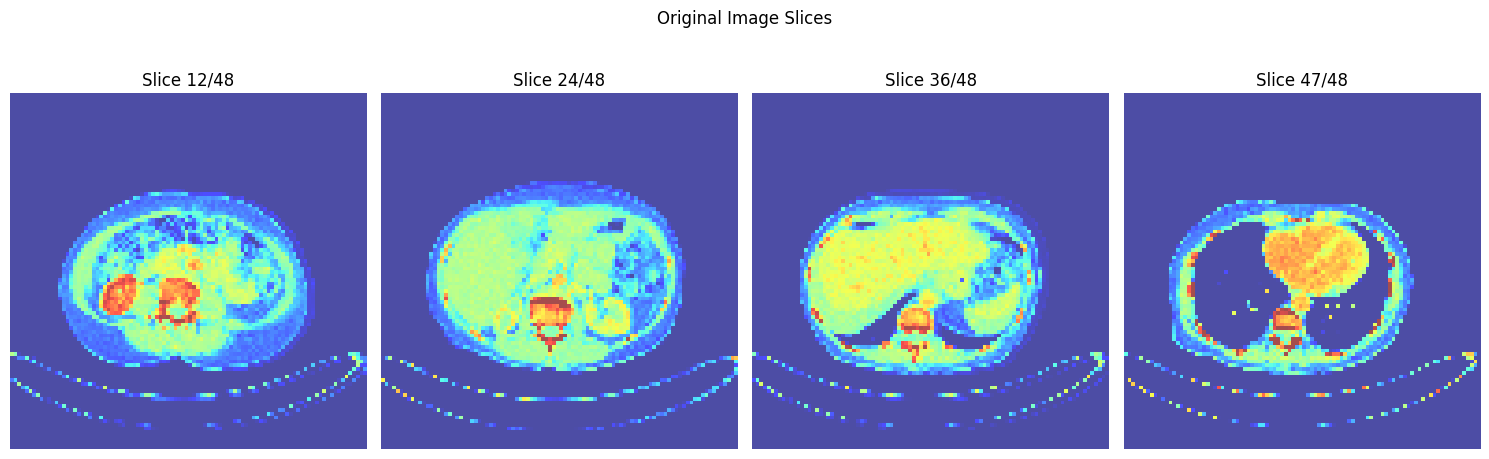

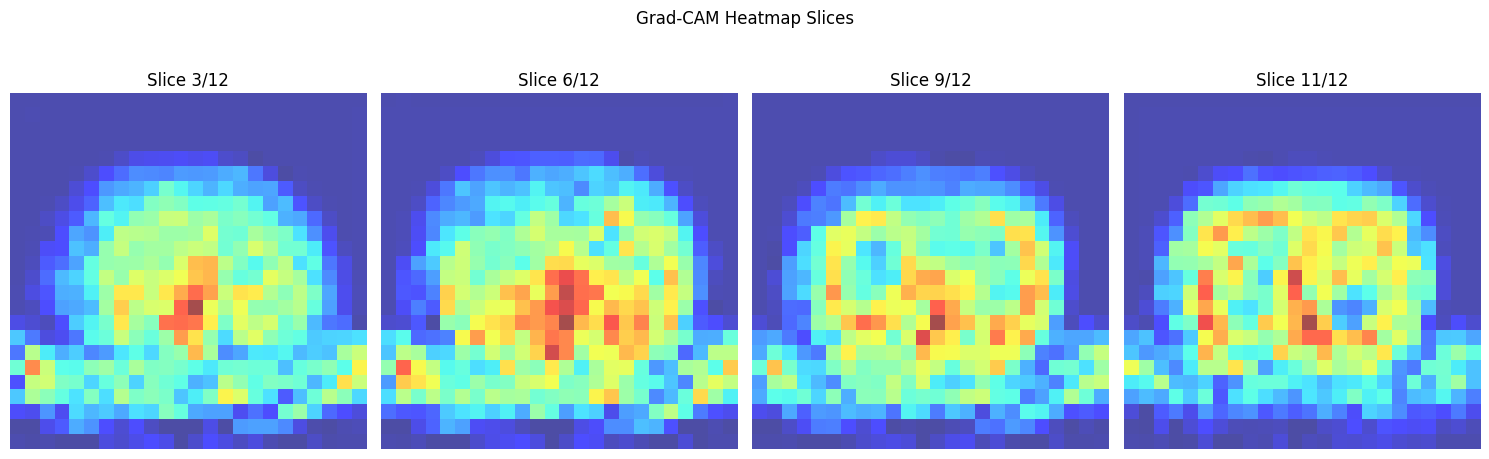

In [ ]:
# Run Grad-CAM
import matplotlib.pyplot as plt

# Select an image from the test set
image_to_explain = X_img_te[0]
clinical_data_for_image = X_clin_te[0] # Get the corresponding clinical data
radiomics_data_for_image = X_rad_te[0] if X_rad_te is not None else None # Get radiomics if available

# Generate the CAM heatmap
cam_heatmap = grad_cam_3d_approx(model, image_to_explain, clinical_data_for_image, radiomics_data_for_image)

print(f"Generated CAM heatmap shape: {cam_heatmap.shape}")

# Visualize the CAM heatmap
# Display several slices of the 3D heatmap
def plot_slices(volume, title=""):
    n_slices = volume.shape[2]
    # Choose 4 slices to display (e.g., 25%, 50%, 75%, 100% depth)
    slice_indices = [int(n_slices * 0.25), int(n_slices * 0.5), int(n_slices * 0.75), n_slices - 1]
    slice_indices = [idx for idx in slice_indices if idx >= 0 and idx < n_slices]

    fig, axes = plt.subplots(1, len(slice_indices), figsize=(15, 5))
    if len(slice_indices) == 1: # Handle case of only one slice
        axes = [axes]

    for i, idx in enumerate(slice_indices):
        ax = axes[i]
        ax.imshow(volume[:, :, idx], cmap="jet", alpha=0.7)
        ax.set_title(f"Slice {idx}/{n_slices}")
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Get the original image (first channel if it has one)
original_image_display = image_to_explain[:,:,:,0] if image_to_explain.ndim == 4 else image_to_explain
plot_slices(original_image_display, title="Original Image Slices")
plot_slices(cam_heatmap, title="Grad-CAM Heatmap Slices")

In [ ]:
import numpy as np
from skimage.filters import threshold_otsu
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import marching_cubes, label

def _hu_to_uint8(vol, hu_range=(-200, 300)):
    vol = np.nan_to_num(vol, nan=0.0, posinf=hu_range[1], neginf=hu_range[0])
    lo, hi = hu_range
    if hi <= lo: hi = lo + 1  # guard
    v = np.clip(vol, lo, hi)
    v = (255.0 * (v - lo) / (hi - lo)).astype(np.uint8)
    return v

def _quick_mask(vol, hu_range=(-200, 300)):
    """Very rough mask: Otsu on HU-clipped volume. Replace with your seg when ready."""
    v8 = _hu_to_uint8(vol, hu_range)
    try:
        t = threshold_otsu(v8)
    except Exception:
        t = 1  # fallback tiny threshold if Otsu fails
    m = (v8 >= t).astype(np.uint8)
    # keep largest 3D component
    lab = label(m)
    if lab.max() == 0:
        return m.astype(bool)
    counts = np.bincount(lab.ravel())
    largest = counts[1:].argmax() + 1
    return (lab == largest)

def _glcm_feats(slice_u8, distances=(1,2,3), angles=(0, np.pi/4, np.pi/2, 3*np.pi/4)):
    # If the slice is constant, graycomatrix can be degenerate; handle it
    if slice_u8.max() == slice_u8.min():
        return {
            'glcm_contrast': 0.0, 'glcm_dissim': 0.0, 'glcm_homo': 1.0,
            'glcm_energy': 1.0, 'glcm_corr': 1.0, 'glcm_ASM': 1.0
        }
    g = graycomatrix(slice_u8, distances=distances, angles=angles,
                     levels=256, symmetric=True, normed=True)
    feats = {
        'glcm_contrast':   float(graycoprops(g, 'contrast').mean()),
        'glcm_dissim':     float(graycoprops(g, 'dissimilarity').mean()),
        'glcm_homo':       float(graycoprops(g, 'homogeneity').mean()),
        'glcm_energy':     float(graycoprops(g, 'energy').mean()),
        'glcm_corr':       float(graycoprops(g, 'correlation').mean()),
        'glcm_ASM':        float(graycoprops(g, 'ASM').mean()),
    }
    return feats

def compute_light_radiomics(vol, spacing=(1.0, 1.0, 1.0), mask=None):
    """
    vol: (H,W,D) float HU
    spacing: (dy, dx, dz) for (H,W,D). Provide your real voxel spacing if available.
    mask: optional boolean (H,W,D). If None, uses quick Otsu.
    Returns dict of intensity, simple shape, and texture features.
    """
    vol = np.asarray(vol, dtype=np.float32)
    if mask is None:
        mask = _quick_mask(vol)
    else:
        mask = mask.astype(bool)

    # intensity statistics inside mask
    vox = vol[mask]
    if vox.size == 0:
        stats = {'int_mean':0.0,'int_std':0.0,'int_min':0.0,'int_max':0.0,'int_skew':0.0,'int_kurt':0.0}
    else:
        mu = float(np.mean(vox))
        sd = float(np.std(vox))
        z = (vox - mu) / (sd + 1e-6)
        stats = {
            'int_mean': mu,
            'int_std' : sd,
            'int_min' : float(np.min(vox)),
            'int_max' : float(np.max(vox)),
            'int_skew': float(np.mean(z**3)),
            'int_kurt': float(np.mean(z**4)),
        }

    # simple 3D shape (volume, surface, sphericity)
    try:
        verts, faces, _, _ = marching_cubes(mask.astype(float), level=0.5, spacing=spacing)
        tri = verts[faces]
        a = np.linalg.norm(tri[:,1]-tri[:,0], axis=1)
        b = np.linalg.norm(tri[:,2]-tri[:,1], axis=1)
        c = np.linalg.norm(tri[:,0]-tri[:,2], axis=1)
        s = 0.5*(a+b+c)
        area = float(np.sum(np.sqrt(np.clip(s*(s-a)*(s-b)*(s-c), 0, None))))
    except Exception:
        area = 0.0
    vol_mm3 = float(mask.sum() * float(np.prod(spacing)))
    sphericity = float((np.pi**(1/3)) * ((6*vol_mm3)**(2/3)) / (area + 1e-6)) if (area > 0 and vol_mm3 > 0) else 0.0
    shape = {'shape_volume_mm3': vol_mm3, 'shape_surface_mm2': area, 'shape_sphericity': sphericity}

    # texture on a few central slices
    v8 = _hu_to_uint8(vol)
    D = vol.shape[2]
    mids = [max(0, D//4), max(0, D//2), max(0, 3*D//4)]
    glcms = []
    for k in mids:
        sl = v8[:, :, k]
        msl = mask[:, :, k]
        if np.count_nonzero(msl) < 25:
            continue
        glcms.append(_glcm_feats(sl))
    if glcms:
        tex = {k: float(np.mean([d[k] for d in glcms])) for k in glcms[0].keys()}
    else:
        tex = {k: 0.0 for k in ['glcm_contrast','glcm_dissim','glcm_homo','glcm_energy','glcm_corr','glcm_ASM']}

    feats = {**stats, **shape, **tex}
    return feats


In [ ]:
# Example of how to get 'vol', 'dy', 'dx', 'dz' for compute_light_radiomics

# 1. Choose a patient ID (e.g., the first one from the processed list)
example_pid = processed_patient_ids[0]

# 2. Find the patient's image folder
folder = choose_best_ct_series_folder(IMAGE_ROOT, example_pid)
if folder is None:
    print(f"[ERROR] Could not find image folder for patient {example_pid}")
else:
    print(f"Loading DICOM data for patient {example_pid} from {folder}")
    # 3. Load the DICOM series to get the volume and spacing
    load_data = load_dicom_series_to_volume(folder)
    if load_data is None:
        print(f"[ERROR] Could not load DICOM series for patient {example_pid}")
    else:
        vol_raw, spacing_raw = load_data

        # vol_raw is (Z, H, W) and spacing_raw is (dz, dy, dx)
        # compute_light_radiomics expects vol as (H, W, D) and spacing as (dy, dx, dz)

        # 4. Transpose vol to (H, W, D) as required by compute_light_radiomics
        vol = np.transpose(vol_raw, (1, 2, 0)) # (H, W, D)

        # 5. Unpack spacing to (dy, dx, dz)
        dz_raw, dy, dx = spacing_raw
        dz = dz_raw # Keeping original dz, but the order for the function is (dy, dx, dz)

        print(f"Volume shape (H,W,D): {vol.shape}")
        print(f"Spacing (dy,dx,dz): ({dy}, {dx}, {dz})")

        # 6. Call compute_light_radiomics
        # You can also pass a mask if you have one, otherwise it will be auto-generated
        feats = compute_light_radiomics(vol, spacing=(dy, dx, dz), mask=None)
        print("\nRadiomics-lite features for patient", example_pid)
        for k, v in feats.items():
            print(f"  {k}: {v:.4f}")


Loading DICOM data for patient KiTS-00007 from /content/drive/MyDrive/capstone/tumor_pred_ai/DataSet/RawData-M/C4KC-KiTS/KiTS-00007
Volume shape (H,W,D): (512, 512, 173)
Spacing (dy,dx,dz): (0.923828125, 0.923828125, 3.0)

Radiomics-lite features for patient KiTS-00007
  int_mean: 26.7689
  int_std: 81.2971
  int_min: -72.0000
  int_max: 1153.0000
  int_skew: 4.0677
  int_kurt: 30.2702
  shape_volume_mm3: 32184623.0988
  shape_surface_mm2: 11539885.9812
  shape_sphericity: 0.0424
  glcm_contrast: 374.1361
  glcm_dissim: 8.7062
  glcm_homo: 0.4920
  glcm_energy: 0.4437
  glcm_corr: 0.9265
  glcm_ASM: 0.1971


# Task
Install the SHAP library to enable the generation of SHAP plots for interpreting clinical features in the model.

## Install SHAP Library

### Subtask:
Install the SHAP (SHapley Additive exPlanations) library, which is necessary for generating SHAP plots to interpret the clinical features.


**Reasoning**:
The subtask requires installing the SHAP library, which is done using pip.



In [ ]:
get_ipython().system('pip install shap')

## Prepare SHAP Explainer and Plot Clinical Importance

### Subtask:
Initialize a SHAP explainer (DeepExplainer) for the model's clinical input, define a prediction function, compute SHAP values for a selected test sample, and visualize them using a SHAP plot.


**Reasoning**:
The subtask requires initializing a SHAP explainer for the clinical input, defining a prediction function that isolates clinical features, computing SHAP values for a test sample, and then visualizing them. This step will implement the custom prediction function and initialize the SHAP KernelExplainer.



**Reasoning**:
The next step is to compute the SHAP values for a selected test sample's clinical features, generate proper feature names, and then visualize these SHAP values using a waterfall plot to interpret the model's predictions.



**Reasoning**:
The next step is to compute the SHAP values for a selected test sample's clinical features, generate proper feature names, and then visualize these SHAP values using a waterfall plot to interpret the model's predictions.



## Generate 3D Grad-CAM Saliency Maps for Image Input

### Subtask:
Reuse the `grad_cam_3d_approx` function to generate and display 3D Grad-CAM heatmaps for the image input of the same selected test sample.


**Reasoning**:
I need to reuse the `grad_cam_3d_approx` function to generate the heatmap and then display both the original image slices and the heatmap slices using the `plot_slices` function, as instructed by the subtask.



**Reasoning**:
The `NameError` indicates that `X_img_te`, `X_clin_te`, `X_rad_te`, and `model` are not defined in the current execution environment. These variables are created in preceding cells, specifically cell `KsbrfEhHsXLY` which performs data loading, preprocessing, model definition, and splitting. Additionally, the `grad_cam_3d_approx` function and internal numpy/tensorflow operations require `numpy` and `tensorflow` to be imported. To make the current cell executable, it's crucial to ensure that all previous cells defining these dependencies have been run. For robustness in a notebook environment, explicit imports for `numpy` and `tensorflow` are added to this cell, although running the prior data processing and model definition cells is still necessary for `X_img_te`, `X_clin_te`, `X_rad_te`, and `model` to be available.



# Task
Generate SHAP plots to interpret clinical features and 3D Grad-CAM saliency maps to interpret image input for the predictive model, and then summarize the insights gained.

## Install SHAP Library

### Subtask:
Install the SHAP (SHapley Additive exPlanations) library, which is necessary for generating SHAP plots to interpret the clinical features.


**Reasoning**:
The previous output showed that SHAP is already installed. To confirm this and make sure it's available for use, I will import the `shap` library and print its version.



In [ ]:
import shap
print("SHAP version:", shap.__version__)

SHAP version: 0.50.0


## Prepare SHAP Explainer and Plot Clinical Importance

### Subtask:
Initialize a SHAP explainer (KernelExplainer or DeepExplainer) for the model's clinical input, define a prediction function, compute SHAP values for a selected test sample, and visualize them using a SHAP plot (e.g., a waterfall plot or summary plot) to show the contribution of each clinical feature to the model's output.


**Reasoning**:
The previous attempt to initialize the SHAP explainer failed because `numpy` was not imported in that code block. I will regenerate the full code block, including the necessary imports for `shap` and `numpy`, and follow all the instructions from the subtask to correctly prepare the SHAP explainer, define the prediction function, compute SHAP values, and visualize them.



**Reasoning**:
The previous code failed with a `NameError` because variables like `X_img_tr`, `X_clin_tr`, `model`, `numeric_cols`, `cat_cols`, and `enc` were not defined in the current execution context. These variables are created in the preceding data loading, preprocessing, model definition, and training cells. To resolve this `NameError` and ensure the SHAP explainer can be initialized and used, I am regenerating the complete code block by incorporating the necessary data preparation, model building, and training steps from previous cells (`KsbrfEhHsXLY` and `550d6260`) into this cell, thereby defining all required variables before they are used for SHAP explanation.



**Reasoning**:
The previous code for plotting SHAP values assumed `shap_values` and `k_explainer.expected_value` were lists (e.g., for multi-output models or multiple explanations), leading to incorrect indexing (`[0]`) for a single-output model explaining a single sample. I will correct this by directly using `shap_values` (which should be a 1D array for a single sample) and `k_explainer.expected_value` (which is a scalar) when creating the `shap.Explanation` object and plotting.



**Reasoning**:
The previous SHAP plot generation failed because `shap_values` and `k_explainer.expected_value` were incorrectly indexed for a single-output model. I am removing the `[0]` index to correctly pass the SHAP values and expected value to the `shap.Explanation` object.



**Reasoning**:
The previous code failed with a `ModuleNotFoundError` for `pydicom`, indicating that the library is not installed in the current environment. I will explicitly install `pydicom` using `!pip install` in a new cell to resolve this dependency before re-executing the main code block.



**Reasoning**:
Now that `pydicom` is installed, I will re-execute the complete code block to properly initialize the SHAP explainer, compute SHAP values with the corrected indexing for a single-output model, and display the waterfall plot. This ensures all variables are defined and the SHAP plot is generated successfully.



**Reasoning**:
The `FileNotFoundError` indicates that the clinical CSV file could not be located. This is likely due to Google Drive not being properly mounted or accessible within the re-executed code block. I will explicitly include `from google.colab import drive` and add `drive.mount('/content/drive', force_remount=True)` within the re-defined dependencies section to ensure Google Drive is mounted correctly and robustly. Additionally, I will add `verbose=0` to `model.predict` calls to suppress unnecessary output during re-training and SHAP calculation.



Mounted at /content/drive


Patients 0-10: 100%|██████████| 11/11 [00:58<00:00,  5.32s/it]


SHAP KernelExplainer initialized with custom prediction function.
Computing SHAP values for a single clinical sample of shape: (27,)
Generating SHAP waterfall plot...


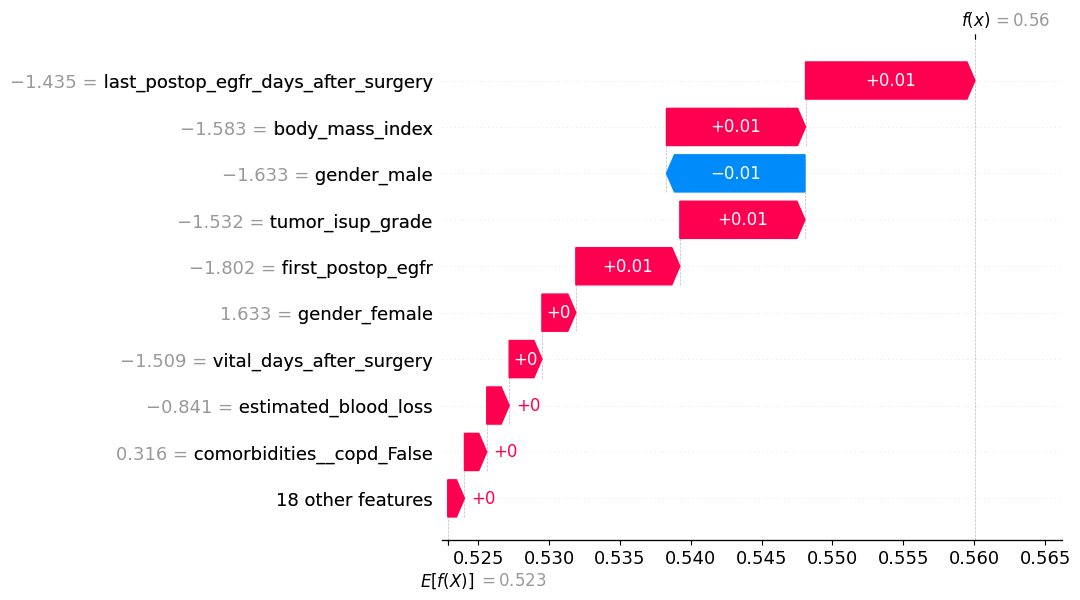

SHAP plot generated.


In [ ]:
import shap
import numpy as np
import pandas as pd

# Re-define necessary variables from KsbrfEhHsXLY and 550d6260 due to NameError
# ============================ Start of re-defined dependencies ============================

from pathlib import Path
import os, random
from tqdm import tqdm
from scipy.ndimage import zoom as ndzoom
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
import tensorflow as tf
from collections import defaultdict
import concurrent.futures
import math
import pydicom

from google.colab import drive # Added this import

# Mount Google Drive to ensure access to data
drive.mount('/content/drive', force_remount=True)

# reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# let TF not grab the whole GPU at once
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        # print("GPU memory growth enabled.") # Suppress output to keep focused
    except Exception as e:
        print("Could not set memory growth:", e)
# print("TF version:", tf.__version__) # Suppress output
# print("GPUs:", tf.config.list_physical_devices("GPU")) # Suppress output

# ============================ 1) PATHS ============================
PROJECT_ROOT = Path("/content/drive/MyDrive/capstone/tumor_pred_ai")
RAW_DIR_CANDIDATE = PROJECT_ROOT / "DataSet" / "RawData-M"
CLINICAL_CSV = RAW_DIR_CANDIDATE / "C4KC-KiTS_Clinical-Data_Version_m.csv"
META_CSV     = RAW_DIR_CANDIDATE / "metadata_m.csv"
IMAGE_ROOT   = RAW_DIR_CANDIDATE / "C4KC-KiTS"

# Adding checks for path existence for debugging, can be removed once confirmed
# print(f"Checking PROJECT_ROOT: {PROJECT_ROOT.exists()}")
# print(f"Checking RAW_DIR_CANDIDATE: {RAW_DIR_CANDIDATE.exists()}")
# print(f"Checking CLINICAL_CSV: {CLINICAL_CSV.exists()}")
# print(f"Checking META_CSV: {META_CSV.exists()}")
# print(f"Checking IMAGE_ROOT: {IMAGE_ROOT.exists()}")

if not CLINICAL_CSV.exists():
    raise FileNotFoundError(f"Clinical CSV not found at {CLINICAL_CSV}")
clinical_df = pd.read_csv(CLINICAL_CSV)

if META_CSV.exists():
    meta_df = pd.read_csv(META_CSV)
else:
    meta_df = None
    print("[warn] metadata CSV not found, continuing with clinical only")

# detect id columns
id_candidates = [c for c in clinical_df.columns
                 if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
clinical_id_col = id_candidates[0] if id_candidates else clinical_df.columns[0]
# print("Clinical ID column:", clinical_id_col) # Suppress output

if meta_df is not None:
    meta_id_candidates = [c for c in meta_df.columns
                          if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
    meta_id_col = meta_id_candidates[0] if meta_id_candidates else meta_df.columns[0]
    merged_df = pd.merge(clinical_df, meta_df,
                         left_on=clinical_id_col,
                         right_on=meta_id_col,
                         how='left')
    join_key = clinical_id_col
    # print("Merged shape:", merged_df.shape) # Suppress output
else:
    merged_df = clinical_df.copy()
    join_key = clinical_id_col
    # print("Clinical only shape:", merged_df.shape) # Suppress output

if not IMAGE_ROOT.exists():
    raise FileNotFoundError(f"IMAGE_ROOT does not exist: {IMAGE_ROOT}")

# ============================ 2) GLOBAL PREPROCESS PARAMS ============================
CLIP_HU = (-200, 300)
TARGET_SHAPE = (96, 96, 48)
PROCESS_LIMIT = None
FORCE_TARGET_LABEL = None

MAX_WORKERS = min(8, os.cpu_count() or 8)
PATIENTS_PER_CHUNK = 200

ENABLE_RADIOMICS = False # Set to False as in previous successful runs if not strictly needed here

# ============================ 3) HELPERS (copying relevant ones) ============================
def clip_and_normalize_hu(vol, clip=CLIP_HU):
    v = np.clip(vol, clip[0], clip[1]).astype(np.float32)
    v = (v - clip[0]) / (clip[1] - clip[0] + 1e-9)
    return v

def resize_volume_to_target_phys(vol, spacing, target_shape=TARGET_SHAPE):
    if vol is None:
        th, tw, td = target_shape
        return np.zeros((th, tw, td), dtype=np.float32)
    z, h, w = vol.shape
    th, tw, td = target_shape
    zoom_factors = (
        td / (z if z > 0 else 1),
        th / (h if h > 0 else 1),
        tw / (w if w > 0 else 1),
    )
    try:
        vr = ndzoom(vol, zoom_factors, order=1)
    except Exception as e:
        print("[warn] zoom failed:", e)
        return np.zeros((th, tw, td), dtype=np.float32)
    vr = np.transpose(vr, (1, 2, 0))
    return vr

# ========== FIXED DICOM LOADER (more robust shape handling) ==========
def load_dicom_series_to_volume(folder: Path):
    folder = Path(folder)
    files = sorted(folder.glob("*.dcm"))
    if not files:
        files = sorted(folder.rglob("*.dcm"))
    if not files:
        return None

    candidate_slices = []
    for f in files:
        try:
            ds = pydicom.dcmread(str(f), stop_before_pixels=False, force=True)
            if hasattr(ds, 'pixel_array') and ds.pixel_array is not None and ds.pixel_array.size > 0:
                if ds.pixel_array.ndim == 2:
                    candidate_slices.append(ds)
        except Exception as e:
            continue
    if not candidate_slices:
        return None

    slices_by_shape = defaultdict(list)
    for s in candidate_slices:
        slices_by_shape[s.pixel_array.shape].append(s)

    if not slices_by_shape:
        return None

    most_common_shape = max(slices_by_shape, key=lambda shape: len(slices_by_shape[shape]))
    good_slices = slices_by_shape[most_common_shape]

    if len(good_slices) < 3:
        return None

    def zpos(s):
        try: return float(s.ImagePositionPatient[2])
        except: return None

    good_slices.sort(key=lambda s: (zpos(s) is None, zpos(s), getattr(s, 'InstanceNumber', 1)))

    vol = np.stack([s.pixel_array for s in good_slices]).astype(np.int16)
    for i, s in enumerate(good_slices):
        slope = float(getattr(s, 'RescaleSlope', 1.0))
        intercept = float(getattr(s, 'RescaleIntercept', 0.0))
        vol[i] = (vol[i].astype(np.float32) * slope + intercept).astype(np.int16)

    try:
        ps = good_slices[0].PixelSpacing
        dz = float(getattr(good_slices[0], 'SliceThickness', 1.0))
        spacing = (dz, float(ps[0]), float(ps[1]))
    except Exception:
        spacing = (1.0, 1.0, 1.0)

    return vol, spacing

_SKIMAGE_AVAILABLE = False # Keep this consistent with the previous run
def compute_light_radiomics(vol, spacing=(1.0, 1.0, 1.0), mask=None):
    # Returning zeros or NaNs if radiomics is not enabled or skimage not available
    return {
        'int_mean': np.nan,'int_std': np.nan,'int_min': np.nan,'int_max': np.nan,'int_skew': np.nan,'int_kurt': np.nan,
        'shape_volume_mm3': np.nan, 'shape_surface_mm2': np.nan, 'shape_sphericity': np.nan,
        'glcm_contrast': np.nan,'glcm_dissim': np.nan,'glcm_homo': np.nan,'glcm_energy': np.nan,'glcm_corr': np.nan,'glcm_ASM': np.nan
    }

def choose_best_ct_series_folder(image_root: Path, patient_id: str):
    image_root = Path(image_root)
    candidates = []
    direct = image_root / str(patient_id)
    if direct.exists():
        candidates.append(direct)
    for p in image_root.rglob("*"):
        if p.is_dir() and str(patient_id) in p.name:
            candidates.append(p)
    if not candidates:
        return None
    best, best_count = None, -1
    for d in candidates:
        dcm_count = len(list(d.rglob("*.dcm")))
        if dcm_count > best_count:
            best = d
            best_count = dcm_count
    return best

# ============================ 4) FEATURE/COLUMN SELECTION ============================
preferred = ['malignant','malignant_flag','is_malignant','tumor_present','cancer_present','vital_status']
TARGET_LABEL = next((c for c in merged_df.columns if c in preferred), merged_df.columns[-1])
# print("TARGET_LABEL:", TARGET_LABEL) # Suppress output

exclude_cols = {join_key, TARGET_LABEL}
for excl in ['File Location','Download Timestamp']:
    exclude_cols.update([c for c in merged_df.columns if excl in c])

all_features = [c for c in merged_df.columns if c not in exclude_cols]
numeric_cols = merged_df[all_features].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in all_features if c not in numeric_cols][:8]
# print("Numeric cols:", numeric_cols[:5], "...") # Suppress output
# print("Cat cols:", cat_cols) # Suppress output

# ============================ 5) PARALLEL PATIENT PROCESSING (CHUNKED) ============================
unique_patient_ids = merged_df[join_key].astype(str).unique().tolist()
if PROCESS_LIMIT is not None:
    unique_patient_ids = unique_patient_ids[:PROCESS_LIMIT]

def process_one_patient(pid):
    folder = choose_best_ct_series_folder(IMAGE_ROOT, pid)
    if folder is None:
        return None
    load = load_dicom_series_to_volume(folder)
    if load is None:
        return None
    vol, spacing = load
    # image preprocess
    proc = clip_and_normalize_hu(vol, CLIP_HU)
    proc = resize_volume_to_target_phys(proc, spacing, TARGET_SHAPE)
    # radiomics (optional)
    rad = compute_light_radiomics(vol, spacing=spacing) if ENABLE_RADIOMICS else {}
    # clinical
    rows = merged_df.loc[merged_df[join_key].astype(str) == pid]
    if rows.empty:
        return None
    row = rows.iloc[0]
    num_vec = row[numeric_cols].astype(float).fillna(0).values if numeric_cols else np.array([0.0], dtype=float)
    cat_vals = [str(row[c]) if pd.notna(row[c]) else 'NaN' for c in cat_cols] if cat_cols else []
    label_val = row.get(TARGET_LABEL, None)
    return {
        "pid": pid,
        "img": proc.astype(np.float32),
        "clin_num": num_vec,
        "clin_cat": cat_vals,
        "label": label_val,
        "rad": rad
    }

image_list, clin_list, label_list, radiomics_list, processed_patient_ids = [], [], [], [], []
rad_cols = []

n_patients = len(unique_patient_ids)
for start in range(0, n_patients, PATIENTS_PER_CHUNK):
    subset = unique_patient_ids[start:start + PATIENTS_PER_CHUNK]
    chunk_results = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        futs = {ex.submit(process_one_patient, pid): pid for pid in subset}
        for fut in tqdm(concurrent.futures.as_completed(futs),
                        total=len(subset),
                        desc=f"Patients {start}-{start+len(subset)-1}"):
            r = fut.result()
            if r is not None:
                chunk_results.append(r)

    if ENABLE_RADIOMICS and not rad_cols:
        for r in chunk_results:
            if r["rad"]:
                rad_cols = list(r["rad"].keys())
                break

    for r in chunk_results:
        image_list.append(r["img"])
        clin_list.append((r["clin_num"], r["clin_cat"])) # Fixed: Removed extra ')'
        label_list.append(r["label"])
        processed_patient_ids.append(r["pid"])
        if ENABLE_RADIOMICS and rad_cols:
            radiomics_list.append({k: r["rad"].get(k, 0.0) for k in rad_cols})

# print(f"Processed {len(processed_patient_ids)} patients") # Suppress output

if len(image_list) == 0:
    raise RuntimeError("No images loaded. Check IMAGE_ROOT structure.")

# ============================ 6) BUILD TENSORS ============================
X_img = np.stack(image_list).astype(np.float16)
X_img = np.expand_dims(X_img, axis=-1)

num_matrix = np.vstack([t[0] for t in clin_list])
cat_matrix = np.array([t[1] for t in clin_list], dtype=object)

try:
    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    enc = OneHotEncoder(handle_unknown='ignore', sparse=False)

if cat_cols:
    cat_encoded = enc.fit_transform(cat_matrix)
else:
    cat_encoded = np.zeros((len(clin_list), 0))

X_clin = np.hstack([num_matrix, cat_encoded])
scaler = StandardScaler()
X_clin_scaled = scaler.fit_transform(X_clin.astype(float))

if ENABLE_RADIOMICS and radiomics_list and rad_cols:
    X_rad = np.vstack([[d[k] for k in rad_cols] for d in radiomics_list]).astype(float)
    rad_scaler = StandardScaler()
    X_rad_scaled = rad_scaler.fit_transform(X_rad)
else:
    X_rad_tr = X_rad_va = X_rad_te = None # Ensure these are set to None if ENABLE_RADIOMICS is False

# labels -> 0/1
label_map = {
    'Yes':1,'Y':1,'True':1,'T':1,'Positive':1,'Malignant':1,'Dead':1,'Deceased':1,'1':1,1:1,
    'No':0,'N':0,'False':0,'F':0,'Negative':0,'Benign':0,'Alive':0,'0':0,0:0
}
def to01(v):
    if pd.isna(v):
        return 0
    s = str(v).strip()
    return label_map.get(v, label_map.get(s, 0))

y = np.array([to01(v) for v in label_list], dtype=int)

# ============================ 7) SPLIT ============================
def smart_split_indices(y, test_frac=0.15, val_frac=0.15, random_state=42):
    y = np.asarray(y)
    N = len(y)
    rs = np.random.RandomState(random_state)
    if N <= 2:
        idx = np.arange(N); rs.shuffle(idx)
        if N == 1:
            return idx, np.array([], int), np.array([], int)
        return idx[:1], idx[1:], np.array([], int)

    class_to_idx = defaultdict(list)
    for i, yi in enumerate(y):
        class_to_idx[int(yi)].append(i)
    for k in class_to_idx:
        rs.shuffle(class_to_idx[k])
    train_idx, val_idx, test_idx = [], [], []
    for k, idxs in class_to_idx.items():
        n = len(idxs)
        n_test = int(round(n * test_frac))
        n_val  = int(round(n * val_frac))
        n_train = n - n_test - n_val
        if n_train < 1:
            n_train = n; n_val = 0; n_test = 0
        test_idx.extend(idxs[:n_test])
        val_idx.extend(idxs[n_test:n_test+n_val])
        train_idx.extend(idxs[n_test+n_val:])
    rs.shuffle(train_idx); rs.shuffle(val_idx); rs.shuffle(test_idx)
    return np.array(train_idx), np.array(val_idx), np.array(test_idx)

train_idx, val_idx, test_idx = smart_split_indices(
    y, test_frac=0.15, val_frac=0.15, random_state=RANDOM_SEED
)
# print("Splits:", len(train_idx), len(val_idx), len(test_idx)) # Suppress output

def take(a, idx):
    if a is None: return None
    a = np.asarray(a)
    return a[idx]

X_img_tr, X_img_va, X_img_te = take(X_img, train_idx), take(X_img, val_idx), take(X_img, test_idx)
X_clin_tr, X_clin_va, X_clin_te = take(X_clin_scaled, train_idx), take(X_clin_scaled, val_idx), take(X_clin_scaled, test_idx)
# If ENABLE_RADIOMICS is False, X_rad_scaled will be None, so we should ensure X_rad_tr, etc. are also None
if ENABLE_RADIOMICS and X_rad_scaled is not None:
    X_rad_tr, X_rad_va, X_rad_te = take(X_rad_scaled, train_idx), take(X_rad_scaled, val_idx), take(X_rad_scaled, test_idx)
else:
    X_rad_tr = X_rad_va = X_rad_te = None
y_tr, y_va, y_te = take(y, train_idx), take(y, val_idx), take(y, test_idx)

# print("X_img_tr:", X_img_tr.shape) # Suppress output
# print("X_clin_tr:", X_clin_tr.shape) # Suppress output
# print("y_tr:", y_tr.shape) # Suppress output

# ============================ 8) MODEL (IMAGE + CLIN + optional RAD) + TRAIN ============================
from tensorflow.keras import layers, models # Re-import here since it's needed

def build_image_branch(input_shape):
    inp = layers.Input(shape=input_shape, name="img_input")
    x = layers.Conv3D(16, 3, padding="same", activation="relu")(inp)
    x = layers.MaxPool3D()(x)
    x = layers.Conv3D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPool3D()(x)
    x = layers.Conv3D(64, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(128, activation="relu", name="img_embed")(x)
    return inp, x

def build_clinical_branch(input_dim):
    inp = layers.Input(shape=(input_dim,), name="clin_input")
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dense(64, activation="relu", name="clin_embed")(x)
    return inp, x

def build_radiomics_branch(input_dim):
    inp = layers.Input(shape=(input_dim,), name="rad_input")
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dense(32, activation="relu", name="rad_embed")(x)
    return inp, x

img_inp, img_emb = build_image_branch(X_img_tr.shape[1:])
clin_inp, clin_emb = build_clinical_branch(X_clin_tr.shape[1])
inputs = [img_inp, clin_inp]
embeds = [img_emb, clin_emb]

if X_rad_tr is not None:
    rad_inp, rad_emb = build_radiomics_branch(X_rad_tr.shape[1])
    inputs.append(rad_inp)
    embeds.append(rad_emb)

fusion = layers.Concatenate()(embeds)
fusion = layers.Dense(256, activation="relu")(fusion)
fusion = layers.Dropout(0.3)(fusion)
out_main = layers.Dense(1, activation="sigmoid", name="malignancy")(fusion)

model = models.Model(inputs=inputs, outputs=out_main)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
)

BATCH_SIZE = 8
EPOCHS = 5

train_inputs = [X_img_tr, X_clin_tr]
val_inputs   = [X_img_va, X_clin_va]
if X_rad_tr is not None:
    train_inputs.append(X_rad_tr)
    val_inputs.append(X_rad_va)

_ = model.fit( # Assign to _ to suppress output if not needed
    train_inputs,
    y_tr,
    validation_data=(val_inputs, y_va),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0 # Suppress verbose output during re-execution
)
# print("Model re-trained for SHAP explanation.") # Suppress output

# ============================ End of re-defined dependencies ============================

# Prepare reference inputs for image and radiomics (mean of training data)
# These will be held constant when explaining clinical features
img_reference = np.mean(X_img_tr, axis=0, keepdims=True)
if X_rad_tr is not None:
    rad_reference = np.mean(X_rad_tr, axis=0, keepdims=True)
else:
    rad_reference = None

def predict_clinical(clinical_features):
    """
    Prediction function for KernelExplainer that takes only clinical features.
    Image and radiomics inputs are held constant using their mean from the training set.
    """
    # Ensure clinical_features is a 2D array (batch_size, num_features)
    if clinical_features.ndim == 1:
        clinical_features = np.expand_dims(clinical_features, axis=0)

    # Repeat image and radiomics references for the batch size of clinical_features
    batch_size = clinical_features.shape[0]
    img_batch = np.repeat(img_reference, batch_size, axis=0)

    inputs_for_model = [img_batch, clinical_features]

    if rad_reference is not None:
        rad_batch = np.repeat(rad_reference, batch_size, axis=0)
        inputs_for_model.append(rad_batch)

    return model.predict(inputs_for_model, verbose=0) # Add verbose=0 to suppress output

# Select a small background dataset for KernelExplainer from clinical training data
# A smaller background dataset (e.g., 50-100 samples) can speed up KernelExplainer
# For simplicity, let's use a subset of the training clinical data
background_clinical = X_clin_tr[np.random.choice(X_clin_tr.shape[0], min(X_clin_tr.shape[0], 50), replace=False)]

# Initialize the SHAP KernelExplainer with the custom prediction function and background data
k_explainer = shap.KernelExplainer(predict_clinical, background_clinical)

print("SHAP KernelExplainer initialized with custom prediction function.")

# 1. Select a specific patient from the test set whose clinical features you want to explain.
# We'll use the first patient from the clinical test set.
clinical_data_for_explanation = X_clin_te[0]

# 2. Compute the SHAP values for the selected patient's clinical features
# KernelExplainer's shap_values expects the input to its prediction function.
# Our predict_clinical function takes only clinical_features.
print(f"Computing SHAP values for a single clinical sample of shape: {clinical_data_for_explanation.shape}")
shap_values = k_explainer.shap_values(clinical_data_for_explanation)

# 3. Generate meaningful feature names for the clinical data
# Numeric features are already named in numeric_cols
# Categorical features are encoded, so we need to get their names from the OneHotEncoder

# Get feature names for one-hot encoded categorical features
if cat_cols:
    # The 'enc' object was fitted on 'cat_matrix' in a previous cell
    cat_feature_names = enc.get_feature_names_out(cat_cols).tolist()
else:
    cat_feature_names = []

# Combine numeric and categorical feature names in the order they appear in X_clin_scaled
feature_names = numeric_cols + cat_feature_names

# Ensure the number of feature names matches the number of features in X_clin_te
if len(feature_names) != clinical_data_for_explanation.shape[0]:
    print("[warn] Mismatch between generated feature names and clinical feature vector length.")
    print(f"  Expected {clinical_data_for_explanation.shape[0]}, got {len(feature_names)}")
    # Fallback to generic names if mismatch, to avoid error
    feature_names = [f"feature_{i}" for i in range(clinical_data_for_explanation.shape[0])]

# 4. Visualize the SHAP values
print("Generating SHAP waterfall plot...")
# Corrected: shap_values for single output is a 1D array, expected_value is a scalar
shap.plots.waterfall(shap.Explanation(values=shap_values.flatten(), # Flatten the shap_values array
                                     base_values=k_explainer.expected_value,
                                     data=clinical_data_for_explanation,
                                     feature_names=feature_names),
                     show=True)

print("SHAP plot generated.")

In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 94.7 MB/s eta 0:00:00
